Train dynamic dataset subsets with the reusable `src.training.trainer` module.

This notebook is a thin execution wrapper around `trainer.py`.

Greetings 

In [1]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train


config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "greeting"),
    model_name="greetings_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result

Device: cpu
Selected labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loaded dataset bundle: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
Dataset samples: 206
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of classes: 10
Dataset shape: (206, 30, 126)
Labels shape: (206,)
Detected input size: 126
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Classes to be trained:
 id            label category
  0     GOOD MORNING GREETING
  1   GOOD AFTERNOON GREETING
  2     GOOD EVENING GREETING
  3            HELLO GREETING
  4      HOW ARE YOU GREETING
  5          IM FINE GREETING
  6 NICE TO MEET YOU GREETING
  7        THANK YOU GREETING
  8    YOURE WELCOME GREETING
  9 SEE YOU TOMORROW GREETING
Train: 144
Validation: 31
Test: 31

Model:
SignLSTM(
  (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
Model classes: 10
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Epoch 01/50 | Train Loss: 2.21

{'model': SignLSTM(
   (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
   (fc): Linear(in_features=128, out_features=10, bias=True)
 ),
 'label_encoder': <src.training.label_encoder.ModelLabelEncoder at 0x13845ee1a30>,
 'history': {'train_loss': [2.215315024058024,
   1.5418110423617892,
   1.1857372389899359,
   0.9797637230820126,
   0.8914493322372437,
   0.806587407986323,
   0.8215771267811457,
   0.785511937406328,
   0.8550986349582672,
   0.7065168031387858,
   0.7088731767402755,
   0.6977632244427999,
   0.7058645172251595,
   0.6326976087358263,
   0.6313650434215864,
   0.6100091056691276,
   0.6549952410989337,
   0.6414902177121904,
   0.6312936486469375,
   0.5761025113364061,
   0.5778587270114157,
   0.600429413219293,
   0.52780339287387,
   0.497308387938473,
   0.45331904788812,
   0.44181592596901786,
   0.450209505442116,
   0.6009733513411548,
   0.5990578217638863],
  'train_acc': [0.2152777777777778,
   0.375,
   0.4236111111111111,
   0.576

Retrain

In [6]:
import sys, torch
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module
trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train

from src.data_collection.dataset_builder import DatasetBuilder

builder = DatasetBuilder()
builder.print_summary()  # Check what you've collected

BUNDLE = REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
MERGED = REPO_ROOT / "data" / "merged_dataset.pt"

X, y = builder.merge_with_bundle(BUNDLE)
torch.save({"X": X, "y": y}, MERGED)
print(f"Saved merged bundle → {MERGED}")


config = TrainingConfig(
    dataset_path=MERGED,
    label_ids=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "greeting"),
    model_name="number_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)
result




Label                          |   ID | Samples
--------------------------------------------------
GOOD MORNING                   |    0 |      39
GOOD AFTERNOON                 |    1 |      36
GOOD EVENING                   |    2 |      36
--------------------------------------------------
TOTAL                          |      |     111

Loaded bundle: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
  Base dataset: 2129 samples, shape (2129, 30, 126)
Merged 111 collected samples into dataset. Total: 2240 samples.
Saved merged bundle → C:\Projects\signia-fsl-recognition\data\merged_dataset.pt
Device: cpu
Selected labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loaded dataset bundle: C:\Projects\signia-fsl-recognition\data\merged_dataset.pt
Dataset samples: 317
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of classes: 10
Dataset shape: (317, 30, 126)
Labels shape: (317,)
Detected input size: 126
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Classes to be traine

{'model': SignLSTM(
   (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
   (fc): Linear(in_features=128, out_features=10, bias=True)
 ),
 'label_encoder': <src.training.label_encoder.ModelLabelEncoder at 0x1e805732ca0>,
 'history': {'train_loss': [2.0127515663388627,
   1.3841512257157407,
   1.1521972558077644,
   0.895245467375846,
   0.7199576869269841,
   0.7084558827305272,
   0.5873475846122292,
   0.9466947802591108,
   0.691680606134337,
   0.5637983221274155,
   0.509047450253327,
   0.6042222151389489,
   0.5161340549520778,
   0.45371139683335077,
   0.4283705812234145,
   0.45432603440133695,
   0.4098278532200809,
   0.4329306191988121,
   0.5826072990894318,
   0.4792766654653247,
   0.3668522327733795,
   0.36244762901267313,
   0.32572622455622813,
   0.3201604396509369,
   0.3385794285465689,
   0.283637790388651,
   0.24900639933698318,
   0.2503454826131665,
   0.2587050557878222,
   0.20807239504286607,
   0.19567280217196067,
   0.184255017852621

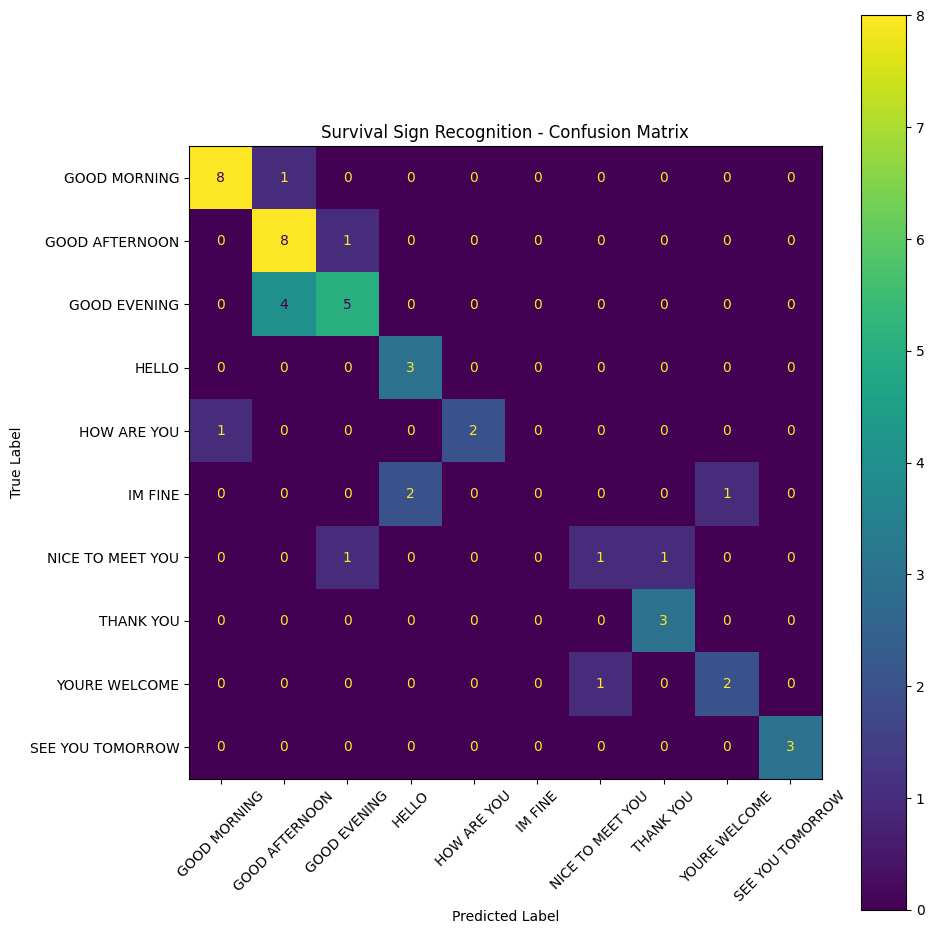

In [ ]:
import sys
import importlib
from pathlib import Path
import torch

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.evaluation.metrics
importlib.reload(src.evaluation.metrics)

from src.evaluation.metrics import plot_confusion_matrix

test_loader = result["test_loader"]
model = result["model"]
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class_names = [
"GOOD MORNING",
"GOOD AFTERNOON",
"GOOD EVENING",
"HELLO",
"HOW ARE YOU",
"IM FINE",
"NICE TO MEET YOU",
"THANK YOU",
"YOURE WELCOME",
"SEE YOU TOMORROW"
]

cm = plot_confusion_matrix(
    model= model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    save_path=(
        REPO_ROOT
        / "artifacts"
        / "models"
        / "survival"
        / "confusion_matrix.png"
    ),
)


import numpy as np

class_accuracy = np.diag(cm) / cm.sum(axis=1)

for label, accuracy in zip(class_names, class_accuracy):
    print(f"{label:20s}: {accuracy:.2%}")

GOOD MORNING        : 88.89%
GOOD AFTERNOON      : 88.89%
GOOD EVENING        : 55.56%
HELLO               : 100.00%
HOW ARE YOU         : 66.67%
IM FINE             : 0.00%
NICE TO MEET YOU    : 33.33%
THANK YOU           : 100.00%
YOURE WELCOME       : 66.67%
SEE YOU TOMORROW    : 100.00%


Survival category

In [1]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train


config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "survival"),
    model_name="survival_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result

Device: cpu
Selected labels: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Loaded dataset bundle: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
Dataset samples: 208
Classes: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of classes: 10
Dataset shape: (208, 30, 126)
Labels shape: (208,)
Detected input size: 126
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Classes to be trained:
 id           label category
 10      UNDERSTAND SURVIVAL
 11 DONT UNDERSTAND SURVIVAL
 12            KNOW SURVIVAL
 13       DONT KNOW SURVIVAL
 14              NO SURVIVAL
 15             YES SURVIVAL
 16           WRONG SURVIVAL
 17         CORRECT SURVIVAL
 18            SLOW SURVIVAL
 19            FAST SURVIVAL
Train: 145
Validation: 31
Test: 32

Model:
SignLSTM(
  (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
Model classes: 10
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Epoch 01/50 | Train L

{'model': SignLSTM(
   (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
   (fc): Linear(in_features=128, out_features=10, bias=True)
 ),
 'label_encoder': <src.training.label_encoder.ModelLabelEncoder at 0x13931c19c40>,
 'history': {'train_loss': [2.2488221579584584,
   1.7018486170933165,
   1.2395258813068784,
   1.0479307322666562,
   0.7214818510515937,
   0.5191764017631267,
   0.45266904255439494,
   0.7036959453261105,
   0.39045184059389704,
   0.2720333161025212,
   0.3920183991049898,
   0.3805298066858588,
   0.18997637716860608,
   0.17233802886872457,
   0.6335569312474851],
  'train_acc': [0.19310344827586207,
   0.38620689655172413,
   0.5103448275862069,
   0.6551724137931034,
   0.8068965517241379,
   0.8620689655172413,
   0.8482758620689655,
   0.7655172413793103,
   0.896551724137931,
   0.9310344827586207,
   0.8896551724137931,
   0.8827586206896552,
   0.9724137931034482,
   0.9793103448275862,
   0.8275862068965517],
  'val_loss': [1.980087195

In [2]:
print(result["best_val_accuracy"])
print(result["test_accuracy"])
print(result["model_path"])
print(result["label_encoder_path"])


1.0
0.875
C:\Projects\signia-fsl-recognition\artifacts\models\survival\survival_lstm_best.pt
C:\Projects\signia-fsl-recognition\artifacts\models\survival\survival_lstm_labels.json


In [5]:
print(result.keys())

dict_keys(['model', 'label_encoder', 'history', 'test_accuracy', 'test_loss', 'best_val_accuracy', 'model_path', 'label_encoder_path'])


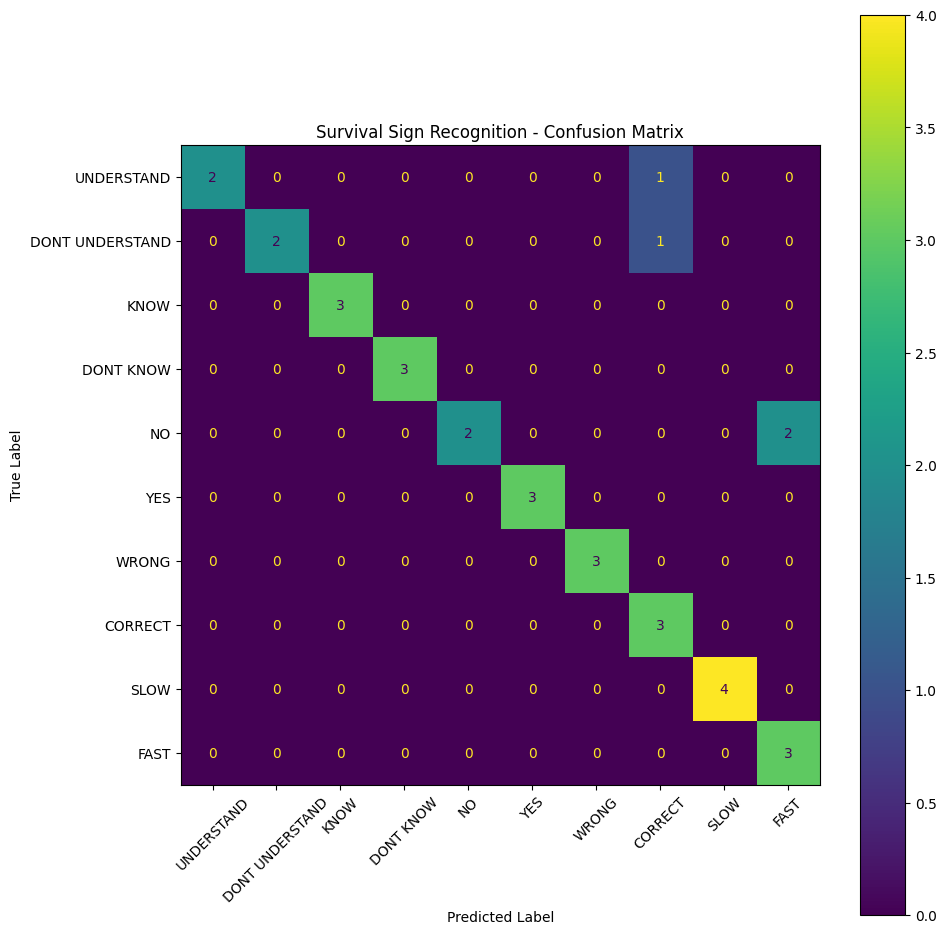

In [7]:
import sys
import importlib
from pathlib import Path
import torch

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.evaluation.metrics
importlib.reload(src.evaluation.metrics)

from src.evaluation.metrics import plot_confusion_matrix

test_loader = result["test_loader"]
model = result["model"]
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class_names = [
    "UNDERSTAND",
    "DONT UNDERSTAND",
    "KNOW",
    "DONT KNOW",
    "NO",
    "YES",
    "WRONG",
    "CORRECT",
    "SLOW",
    "FAST",
]

cm = plot_confusion_matrix(
    model= model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    save_path=(
        REPO_ROOT
        / "artifacts"
        / "models"
        / "survival"
        / "confusion_matrix.png"
    ),
)

In [8]:
import numpy as np

class_accuracy = np.diag(cm) / cm.sum(axis=1)

for label, accuracy in zip(class_names, class_accuracy):
    print(f"{label:20s}: {accuracy:.2%}")

UNDERSTAND          : 66.67%
DONT UNDERSTAND     : 66.67%
KNOW                : 100.00%
DONT KNOW           : 100.00%
NO                  : 50.00%
YES                 : 100.00%
WRONG               : 100.00%
CORRECT             : 100.00%
SLOW                : 100.00%
FAST                : 100.00%


In [15]:
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import importlib
import src.evaluation.metrics

importlib.reload(src.evaluation.metrics)

from src.evaluation.metrics import (
    get_test_predictions,
    get_classification_report,
)


from src.evaluation.metrics import (
    get_test_predictions,
    get_classification_report,
)

y_true, y_pred = get_test_predictions(
    model=result["model"],
    test_loader=result["test_loader"],
    device=device,
)

report = get_classification_report(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
)

import pandas as pd

report_df = pd.DataFrame(report).T

report_df


,precision,recall,f1-score,support
UNDERSTAND,1.000,0.666667,0.800000,3.000
DONT UNDERSTAND,1.000,0.666667,0.800000,3.000
KNOW,1.000,1.000000,1.000000,3.000
DONT KNOW,1.000,1.000000,1.000000,3.000
NO,1.000,0.500000,0.666667,4.000
YES,1.000,1.000000,1.000000,3.000
WRONG,1.000,1.000000,1.000000,3.000
CORRECT,0.600,1.000000,0.750000,3.000
SLOW,1.000,1.000000,1.000000,4.000
FAST,0.600,1.000000,0.750000,3.000


In [16]:
print("result test accuracy:", result["test_accuracy"])

correct = sum(
    int(a == b)
    for a, b in zip(y_true, y_pred)
)

total = len(y_true)

print("classification accuracy:", correct / total)
print("correct:", correct)
print("total:", total)

result test accuracy: 0.875
classification accuracy: 0.875
correct: 28
total: 32


In [22]:
import pandas as pd
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


manifest = pd.read_csv(
"C:\\Projects\\signia-fsl-recognition\\data\\video_manifest.csv"
)

survival = manifest[
    (manifest["category"] == "SURVIVAL") |
    (manifest["enabled"] == True)
]

print(
    survival.groupby(
        ["label_id", "label"]
    ).size()
)


label_id  label          
10        UNDERSTAND         20
11        DONT UNDERSTAND    21
12        KNOW               21
13        DONT KNOW          20
14        NO                 21
15        YES                20
16        WRONG              21
17        CORRECT            22
18        SLOW               21
19        FAST               21
dtype: int64


In [23]:
import torch
from collections import Counter

data = torch.load(
    REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt",
    weights_only=False,
)

print(data.keys())

dict_keys(['X', 'y'])
